In [145]:
import pandas as pd


In [146]:
df = pd.read_csv('winequality-red.csv')

In [147]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [148]:
df.shape

(1599, 12)

In [149]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [150]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [151]:
df.duplicated().sum()

np.int64(240)

In [152]:
df = df.drop_duplicates()

In [153]:
df['quality'].value_counts().sort_index()

quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64

In [154]:
def quality_to_class(q):
    if q in [3, 4]:
        return 0
    elif q in [5, 6]:
        return 1
    else:
        return 2


In [155]:
df['quality_class'] = df['quality'].apply(quality_to_class)

C:\Users\shaki\AppData\Local\Temp\ipykernel_26776\2918696795.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['quality_class'] = df['quality'].apply(quality_to_class)


In [156]:
df[['quality', 'quality_class']]

,quality,quality_class
0,5,1
1,5,1
2,5,1
3,6,1
5,5,1
...,...,...
1593,6,1
1594,5,1
1595,6,1
1597,5,1


In [157]:
X = df.drop(['quality', 'quality_class'], axis=1)
y = df['quality_class']

In [158]:
X.shape

(1359, 11)

In [159]:
y.shape

(1359,)

In [160]:
from sklearn.model_selection import train_test_split

In [161]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [162]:
X_train.shape

(1087, 11)

In [163]:
X_test.shape

(272, 11)

In [164]:
from sklearn.tree import DecisionTreeClassifier

In [165]:
model = DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=3)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [166]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, precision_score

In [167]:
accuracy_score(y_test, y_pred)

0.8308823529411765

In [168]:
confusion_matrix(y_test, y_pred)

array([[  0,  13,   0],
       [  3, 210,   9],
       [  0,  21,  16]])

In [169]:
f1_score(y_test, y_pred, average='weighted')

0.8058184231743368

In [170]:
precision_score(y_test, y_pred, average='weighted')
#todo find reason behind wighted

0.7895057859209258

In [171]:
model.score(X_test, y_test)


0.8308823529411765

In [172]:
model.feature_importances_

array([0.        , 0.09908522, 0.        , 0.        , 0.        ,
       0.        , 0.05104678, 0.        , 0.        , 0.29416485,
       0.55570315])

In [173]:
import pandas as pd

In [174]:
pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

alcohol                 0.555703
sulphates               0.294165
volatile acidity        0.099085
total sulfur dioxide    0.051047
fixed acidity           0.000000
citric acid             0.000000
residual sugar          0.000000
free sulfur dioxide     0.000000
chlorides               0.000000
pH                      0.000000
density                 0.000000
dtype: float64

In [175]:
sample = X_test.iloc[[0]]
actual = y_test.iloc[0]
prediction = model.predict(sample)
print('predicted: ', prediction[0])
print('actual: ', actual)

predicted:  1
actual:  1


In [176]:
import matplotlib.pyplot as plt
from sklearn.tree import  plot_tree

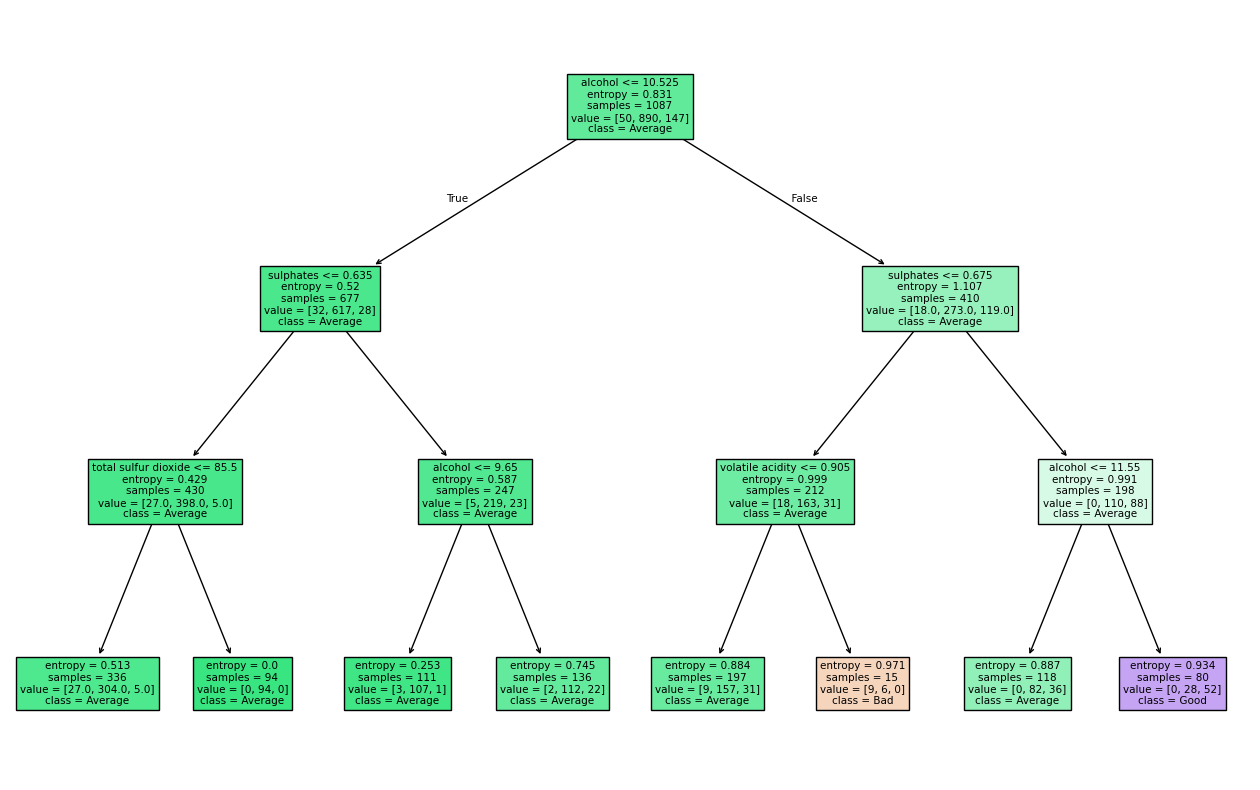

In [177]:
plt.figure(figsize=(16, 10))
plot_tree(model, filled=True, feature_names=X.columns, class_names=['Bad', 'Average', 'Good'])
plt.show()

In [178]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

In [179]:
cv_model = DecisionTreeClassifier(random_state=0, criterion='entropy')
cv_scores = cross_val_score(cv_model, X, y, cv=5)

print("Cross validation scores: ", cv_scores)
print("Average cross validation score: ", cv_scores.mean())
print("standard deviation: ", cv_scores.std())

Cross validation scores:  [0.77573529 0.75       0.73529412 0.72426471 0.69372694]
Average cross validation score:  0.7358042109832863
standard deviation:  0.027202680612292654
